# ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Este notebook contiene el análisis inicial de los datos para el trabajo de métodos supervisados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple


# Configuración de semilla para reproducibilidad (Regla del Máster)
SEED = 42
np.random.seed(SEED)

# Carga de datos
train_path = 'data/training.csv'
test_path = 'data/test.csv'

try:
    train_df = pd.read_csv(train_path, index_col=0)
    test_df = pd.read_csv(test_path, index_col=0)

    print(f"Dimensiones entrenamiento: {train_df.shape}")
    print(f"Dimensiones prueba: {test_df.shape}")
    
    # Mostrar las primeras filas
    display(train_df.head())
except FileNotFoundError as e:
    print(f"Error al cargar los archivos: {e}")

Dimensiones entrenamiento: (3000, 51)
Dimensiones prueba: (2000, 51)


,bqwyz,glhls,gwrec,bpsmt,csuhz,dsdfq,dhmrb,qimhg,dnywb,bbznq,...,dbcsa,vieby,mpqtr,vxswx,xpwzl,vbsda,fiptu,jahkp,ownqd,class
1,-12.993810,-3.689143,6.000694,17.215317,15.319216,0.003135,17.779791,16.248288,0.253989,-17.427260,...,0.616191,-1.037537,0.640160,-1.586657,1.786693,0.854592,-1.318690,-0.317202,1.387131,1
2,6.246265,1.764485,-3.318136,15.920140,15.471565,0.012288,-8.952036,16.345302,1.098853,-4.312381,...,-1.436535,0.439239,0.298879,-0.401065,1.441416,-0.617473,-0.137313,1.982024,1.249828,0
3,-3.039952,-0.262428,1.168803,-13.059538,-13.989008,0.022966,2.920655,-12.881768,0.795419,3.261357,...,-1.371939,1.531874,-0.156040,-0.795904,0.114599,-0.416141,0.050341,0.200234,1.222475,0
4,-10.644402,-3.330536,5.633811,-11.523825,-11.433825,0.030853,14.704378,-11.115733,1.379458,-16.017284,...,0.060147,0.547056,-1.044690,0.636920,0.376566,-1.013476,-0.710287,1.150738,0.391557,0
5,-4.488924,-1.091610,2.512258,1.073196,2.646280,0.027421,5.430353,2.135076,1.212872,-28.630766,...,-1.371114,2.015222,1.064987,3.702119,1.460052,1.066106,-0.798662,1.337375,1.524883,1


## 1. Análisis de la Variable Objetivo (`class`)

### Teoría: Balanceo de Clases
El desbalanceo de clases ocurre cuando las categorías del conjunto de datos no están representadas equitativamente. En investigación, esto es crítico ya que modelos entrenados con datos desbalanceados tienden a ignorar la clase minoritaria, afectando métricas como el F1-Score o el Recall. 

Vamos a verificar el conteo y la proporción de cada clase.

Reporte de Balanceo de Clases:


,Frecuencia Absoluta,Proporción (%)
class,,
0,2060,68.666667
1,921,30.700000
2,19,0.633333


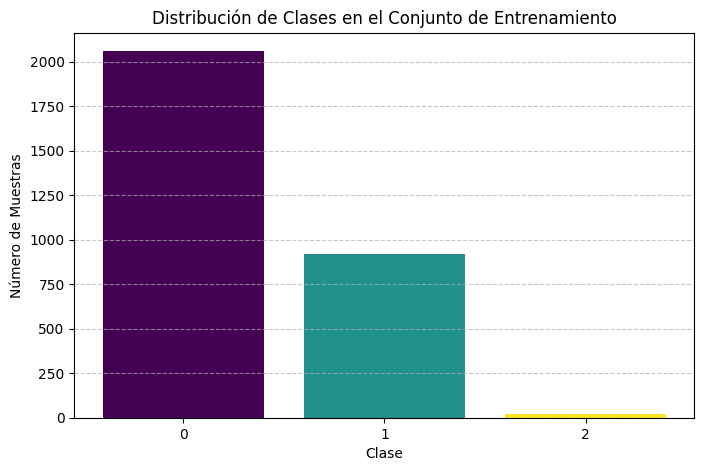

In [2]:
# Cálculo de frecuencias absolutas y relativas
class_counts = train_df['class'].value_counts().sort_index()
class_proportions = train_df['class'].value_counts(normalize=True).sort_index() * 100

# Creación de un DataFrame para visualización tabular
balance_report = pd.DataFrame({
    'Frecuencia Absoluta': class_counts,
    'Proporción (%)': class_proportions
})

print("Reporte de Balanceo de Clases:")
display(balance_report)

# Visualización gráfica con Matplotlib puro (evitando dependencias externas faltantes)
plt.figure(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(class_counts)))
plt.bar(class_counts.index.astype(str), class_counts.values, color=colors)
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Clase')
plt.ylabel('Número de Muestras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Análisis de Valores Nulos

### Teoría: Valores Faltantes (Missing Values)
Los **valores nulos o faltantes** (`NaN`, `None`) son uno de los problemas más comunes en conjuntos de datos reales. Su presencia puede afectar gravemente el rendimiento de los modelos supervisados por varias razones:

- **Sesgo del modelo**: si los datos faltantes no son aleatorios (MNAR — Missing Not At Random), ignorarlos introduce sesgo.
- **Errores en entrenamiento**: la mayoría de algoritmos de ML no aceptan NaN de forma nativa y fallan si no se tratan.
- **Pérdida de información**: eliminar filas con nulos puede reducir significativamente el tamaño del dataset.

**Tipos de missing values:**
| Tipo | Sigla | Descripción |
|------|-------|-------------|
| Missing Completely At Random | MCAR | La ausencia es aleatoria e independiente de los datos |
| Missing At Random | MAR | La ausencia depende de otras variables observadas |
| Missing Not At Random | MNAR | La ausencia depende del propio valor faltante |

A continuación analizamos la presencia de nulos en **train** y **test** por variable.

In [3]:
# ── 2. ANÁLISIS DE VALORES NULOS ─────────────────────────────────────────────

def resumen_nulos(df, nombre):
    """Genera un DataFrame resumen con conteo y porcentaje de nulos por columna."""
    total_filas = len(df)
    nulos = df.isnull().sum()
    pct_nulos = (nulos / total_filas * 100).round(2)
    resumen = pd.DataFrame({
        'Variable': nulos.index,
        'Nulos': nulos.values,
        'Porcentaje (%)': pct_nulos.values,
        'Tipo': df.dtypes.values
    })
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
    print(f"\n{'='*55}")
    print(f"  Dataset: {nombre} | Filas: {total_filas} | Columnas: {df.shape[1]}")
    print(f"{'='*55}")
    if resumen.empty:
        print("  ✅ No se encontraron valores nulos en ninguna variable.")
    else:
        print(f"  ⚠️  Variables con nulos: {len(resumen)} de {df.shape[1]}")
        display(resumen.reset_index(drop=True))
    return resumen

# Resumen tabular para train y test
nulos_train = resumen_nulos(train_df, 'Training')
nulos_test  = resumen_nulos(test_df,  'Test')


  Dataset: Training | Filas: 3000 | Columnas: 51
  ✅ No se encontraron valores nulos en ninguna variable.

  Dataset: Test | Filas: 2000 | Columnas: 51
  ⚠️  Variables con nulos: 1 de 51


,Variable,Nulos,Porcentaje (%),Tipo
0,class,2000,100.0,float64


### 3. ESCALAS DE DATOS

### Teoría: Escalamiento de Datos

El escalamiento es un paso crítico en el preprocesamiento de datos para muchos algoritmos de aprendizaje supervisado (como SVM, KNN o Redes Neuronales). 

**¿Por qué es necesario?**
- **Magnitudes dispares**: Si una variable tiene un rango de [0, 1] y otra de [0, 1000], el algoritmo puede dar más peso erróneamente a la variable con mayores valores.
- **Convergencia**: Los algoritmos basados en gradiente convergen mucho más rápido con datos escalados.

Antes de aplicar cualquier transformación, usamos `.describe()` para observar los estadísticos descriptivos (media, desviación estándar, min, max) y ver si las variables tienen rangos muy distintos.

In [4]:
# ── 3. ANÁLISIS DESCRIPTIVO (Previo al escalamiento) ─────────────────────────

print("Estadísticos descriptivos del conjunto de Entrenamiento:")
display(train_df.describe().T)

print("\nEstadísticos descriptivos del conjunto de Prueba:")
display(test_df.describe().T)

Estadísticos descriptivos del conjunto de Entrenamiento:


,count,mean,std,min,25%,50%,75%,max
bqwyz,3000.0,-0.004300,7.163009,-26.218773,-4.827312,0.034779,4.960671,26.913768
glhls,3000.0,-0.011758,2.244662,-8.292004,-1.524560,0.008314,1.545557,8.254727
gwrec,3000.0,0.010927,3.694104,-13.002065,-2.516686,-0.033044,2.481371,13.724686
bpsmt,3000.0,0.027608,17.275826,-53.039906,-11.608364,-0.193234,11.523221,65.669110
csuhz,3000.0,0.018514,17.277146,-52.864002,-11.588632,-0.171462,11.804511,65.440448
dsdfq,3000.0,0.016405,0.009467,0.000002,0.008139,0.016570,0.024734,0.032290
dhmrb,3000.0,0.030222,10.147739,-36.287098,-7.013635,0.001265,6.884993,38.362303
qimhg,3000.0,0.012773,17.245961,-51.950337,-11.545322,-0.250436,11.669142,64.846963
dnywb,3000.0,0.845216,0.489306,0.000369,0.417733,0.836263,1.275600,1.680864
bbznq,3000.0,0.115831,19.357858,-71.931730,-13.347472,0.479125,13.238516,69.760769



Estadísticos descriptivos del conjunto de Prueba:


,count,mean,std,min,25%,50%,75%,max
bqwyz,2000.0,-0.015043,7.318138,-24.719874,-5.026756,-0.138727,5.130952,24.402675
glhls,2000.0,0.003098,2.293745,-7.589526,-1.559375,-0.055820,1.640986,7.960800
gwrec,2000.0,0.003897,3.771760,-12.397367,-2.603811,0.099553,2.572389,12.603741
bpsmt,2000.0,-0.183866,17.071554,-56.136950,-11.955942,-0.415471,11.568828,58.210455
csuhz,2000.0,-0.206722,17.061326,-56.084486,-11.761952,-0.426202,11.262784,57.751614
dsdfq,2000.0,0.016431,0.009269,0.000009,0.008618,0.016552,0.024306,0.032294
dhmrb,2000.0,-0.000561,10.361973,-33.812735,-7.284889,0.199136,7.248451,34.209152
qimhg,2000.0,-0.189155,17.053272,-56.033757,-11.847266,-0.352504,11.586997,57.614543
dnywb,2000.0,0.824956,0.483995,0.000169,0.411109,0.819362,1.236954,1.681323
bbznq,2000.0,0.042931,19.811859,-73.286004,-13.045043,0.242580,12.962711,70.740789


## 4. Deteccion de Outliers

### Teoria: Valores Atipicos (Outliers)
Los **outliers** son observaciones que se alejan significativamente del resto de los datos. Su presencia puede distorsionar los modelos supervisados, especialmente los basados en distancias (KNN, SVM) o en maximos/minimos (arboles de decision).

**Metodo IQR (Rango Intercuartilico):**
Es el metodo mas robusto frente a distribuciones no normales. Define los limites:
- `Limite inferior = Q1 - 1.5 * IQR`
- `Limite superior = Q3 + 1.5 * IQR`
Cualquier valor fuera de estos limites se considera outlier.

**Estrategia de visualizacion:**
Con 50 variables, un unico grafico resultaria ilegible. Usamos:
1. **Tabla resumen**: porcentaje de outliers por variable, ordenado de mayor a menor.
2. **Grid de boxplots** (variables normalizadas en grupos de 10): permite comparar la dispersion y los extremos de cada variable.
3. **Heatmap de tasa de outliers**: vision global de que variables concentran mas valores atipicos.


In [5]:
# == 4. DETECCION DE OUTLIERS (Metodo IQR) ====================================
import math

# --- Seleccionar solo columnas numericas (excluir la variable objetivo) ------
feature_cols = [c for c in train_df.select_dtypes(include='number').columns if c != 'class']

# --- Funcion: calcular outliers via IQR -------------------------------------
def calcular_outliers_iqr(df, columnas):
    registros = []
    for col in columnas:
        serie = df[col].dropna()
        Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        mask = (serie < lim_inf) | (serie > lim_sup)
        registros.append({
            'Variable'        : col,
            'Q1'              : round(Q1, 3),
            'Q3'              : round(Q3, 3),
            'IQR'             : round(IQR, 3),
            'Lim. Inferior'   : round(lim_inf, 3),
            'Lim. Superior'   : round(lim_sup, 3),
            'N Outliers'      : int(mask.sum()),
            'Outliers (%)'    : round(mask.mean() * 100, 2),
        })
    return pd.DataFrame(registros).sort_values('Outliers (%)', ascending=False).reset_index(drop=True)

# --- Calcular para train y test ----------------------------------------------
out_train = calcular_outliers_iqr(train_df, feature_cols)
out_test  = calcular_outliers_iqr(test_df,  feature_cols)

print('Resumen de Outliers - Training:')
display(out_train)
print('\nResumen de Outliers - Test:')
display(out_test)


Resumen de Outliers - Training:


,Variable,Q1,Q3,IQR,Lim. Inferior,Lim. Superior,N Outliers,Outliers (%)
0,desog,-6.598,6.413,13.011,-26.115,25.930,36,1.20
1,ownqd,0.207,1.783,1.576,-2.158,4.148,34,1.13
2,xpwzl,-0.740,0.793,1.532,-3.038,3.091,34,1.13
3,woerw,-1.875,1.968,3.842,-7.638,7.731,33,1.10
4,nihms,-9.528,9.695,19.223,-38.362,38.529,33,1.10
5,gkbbj,-3.035,3.007,6.042,-12.098,12.070,31,1.03
6,fiptu,-0.752,0.737,1.490,-2.987,2.972,29,0.97
7,vbsda,-0.746,0.771,1.517,-3.021,3.045,29,0.97
8,qbzae,-0.177,0.197,0.374,-0.738,0.759,28,0.93
9,tzehd,-6.389,6.841,13.231,-26.235,26.687,27,0.90



Resumen de Outliers - Test:


,Variable,Q1,Q3,IQR,Lim. Inferior,Lim. Superior,N Outliers,Outliers (%)
0,fiptu,-0.820,0.737,1.557,-3.156,3.073,25,1.25
1,vbsda,-0.832,0.717,1.549,-3.155,3.040,24,1.20
2,mpqtr,-0.778,0.700,1.478,-2.995,2.917,24,1.20
3,mesva,0.227,1.738,1.511,-2.039,4.004,24,1.20
4,dbcsa,-0.766,0.772,1.537,-3.072,3.078,23,1.15
5,xpwzl,-0.826,0.676,1.502,-3.079,2.929,22,1.10
6,vughm,-5.948,5.663,11.611,-23.364,23.080,21,1.05
7,bbznq,-13.045,12.963,26.008,-52.057,51.974,20,1.00
8,tlffs,-0.819,0.684,1.503,-3.074,2.938,19,0.95
9,ownqd,0.272,1.792,1.520,-2.007,4.072,19,0.95


## 5. Distribucion de las Variables (Train)

### Teoria: Distribucion de los datos
Conocer la distribucion de cada variable es fundamental antes de elegir un modelo:

- **Distribucion normal (Gaussiana)**: media = mediana, simetria, campana. Favorece modelos como la Regresion Logistica o LDA.
- **Distribucion sesgada (skewed)**: la cola se extiende hacia un lado. Puede requerir transformaciones (log, Box-Cox).
- **Distribucion bimodal**: dos picos, puede indicar la mezcla de dos subpoblaciones.
- **Distribucion uniforme**: todos los valores igualmente probables. Poco informativa sin contexto.

Usamos un **histograma** para estimar la frecuencia empirica y una **curva KDE** (Kernel Density Estimation) para suavizar la distribucion continua subyacente. El grid multiplot agrupa las 50 variables en una unica figura navegable.


Las 5 variables con mayor correlacion absoluta con la clase son: ['ownqd', 'mesva', 'jahkp', 'vieby', 'qfogt']


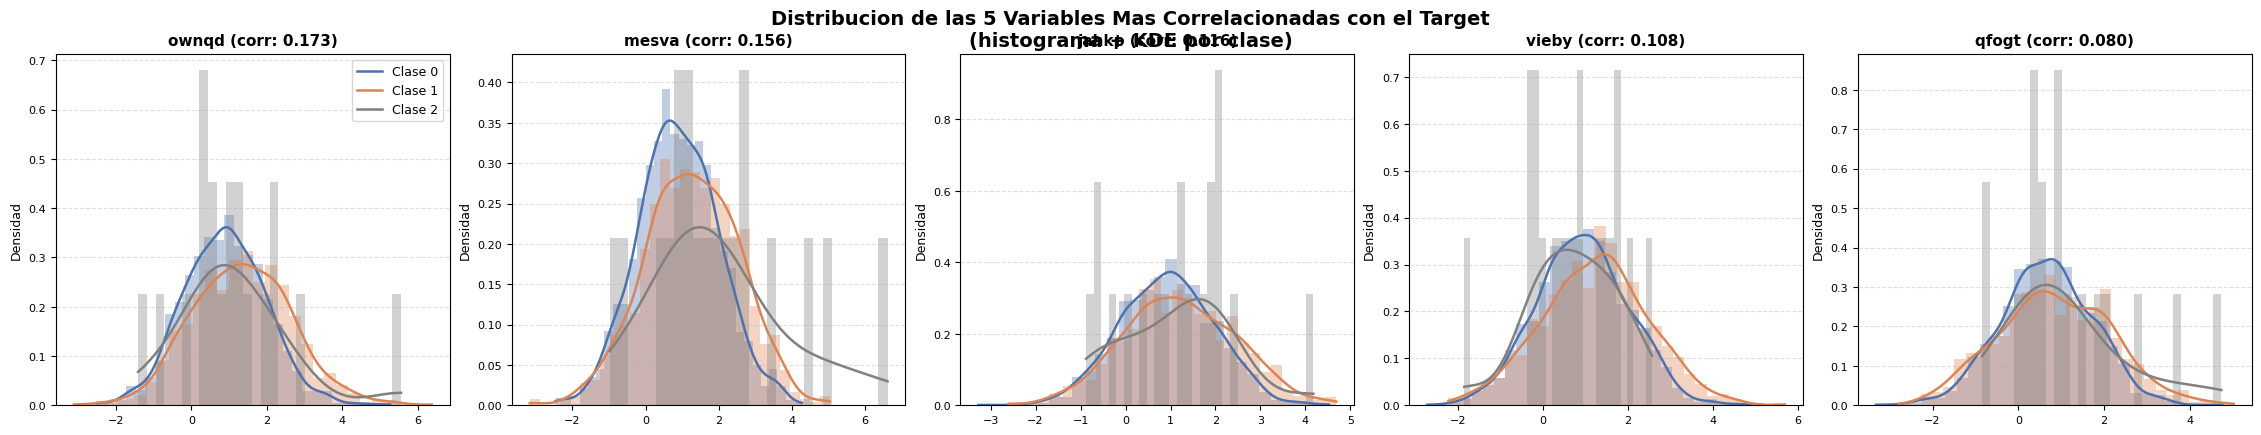

In [6]:
# == 5. DISTRIBUCION DE LAS 5 VARIABLES MAS CORRELACIONADAS ===================
from scipy.stats import gaussian_kde
import math

# 1. Calcular la correlacion de todas las variables con 'class'
corr_with_class = train_df.corr(method='pearson')['class'].drop('class').dropna()

# 2. Seleccionar las 5 variables con mayor correlacion (en valor absoluto)
top_5_vars = corr_with_class.abs().sort_values(ascending=False).head(5).index.tolist()
print(f"Las 5 variables con mayor correlacion absoluta con la clase son: {top_5_vars}")

N_COLS = min(5, len(top_5_vars))
N_ROWS = math.ceil(len(top_5_vars) / N_COLS)

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 4.5, N_ROWS * 4),
    constrained_layout=True,
    squeeze=False
)
axes_flat = axes.flatten()

# Paleta por clase para comparar distribuciones
palette = {0: '#4C72B0', 1: '#DD8452'}
clases  = sorted(train_df['class'].dropna().unique())

for i, col in enumerate(top_5_vars):
    ax = axes_flat[i]
    for cls in clases:
        datos = train_df.loc[train_df['class'] == cls, col].dropna()
        color = palette.get(cls, 'grey')

        # Histograma normalizado
        ax.hist(datos, bins=30, color=color, alpha=0.35, density=True)

        # Curva KDE
        if len(datos) > 1 and datos.std() > 0:
            kde   = gaussian_kde(datos, bw_method='scott')
            x_rng = np.linspace(datos.min(), datos.max(), 200)
            ax.plot(x_rng, kde(x_rng), color=color, linewidth=1.8,
                    label=f'Clase {int(cls)}')

    ax.set_title(f'{col} (corr: {corr_with_class[col]:.3f})', fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('')
    ax.set_ylabel('Densidad', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(fontsize=9, loc='upper right')

# Ocultar ejes sobrantes (si los hubiera)
for ax in axes_flat[len(top_5_vars):]:
    ax.set_visible(False)

fig.suptitle(
    'Distribucion de las 5 Variables Mas Correlacionadas con el Target\n'
    '(histograma + KDE por clase)',
    fontsize=14, fontweight='bold', y=1.05
)
plt.show()

## 6. Analisis de Correlacion

### Teoria: ¿Por que medir la correlacion?
La correlacion lineal (Pearson) mide el grado en que dos variables fluctuan juntas, en un rango normalizado de -1 a +1.

- **Correlacion con la variable objetivo (`class`)**: Nos indica el poder predictivo bruto de cada caracteristica. Si una variable tiene una correlacion cercana a +1 o -1, es un predictor estelar por si sola.
- **Correlacion entre variables predictoras (Multicolinealidad)**: Si dos variables de entrada tienen una correlacion muy alta (ej. > 0.8), significa que aportan la misma informacion al modelo. En modelos como la regresion lineal o logistica, la multicolinealidad inestabiliza los coeficientes y suele compensar eliminar una de las variables.

**Visualizacion:**
1. **Ranking (Bar chart)**: Correlacion de cada variable frente al target (`class`).
2. **Heatmap Global**: Matriz diagonal de calor para ver clusters de alta correlacion entre predictoras.


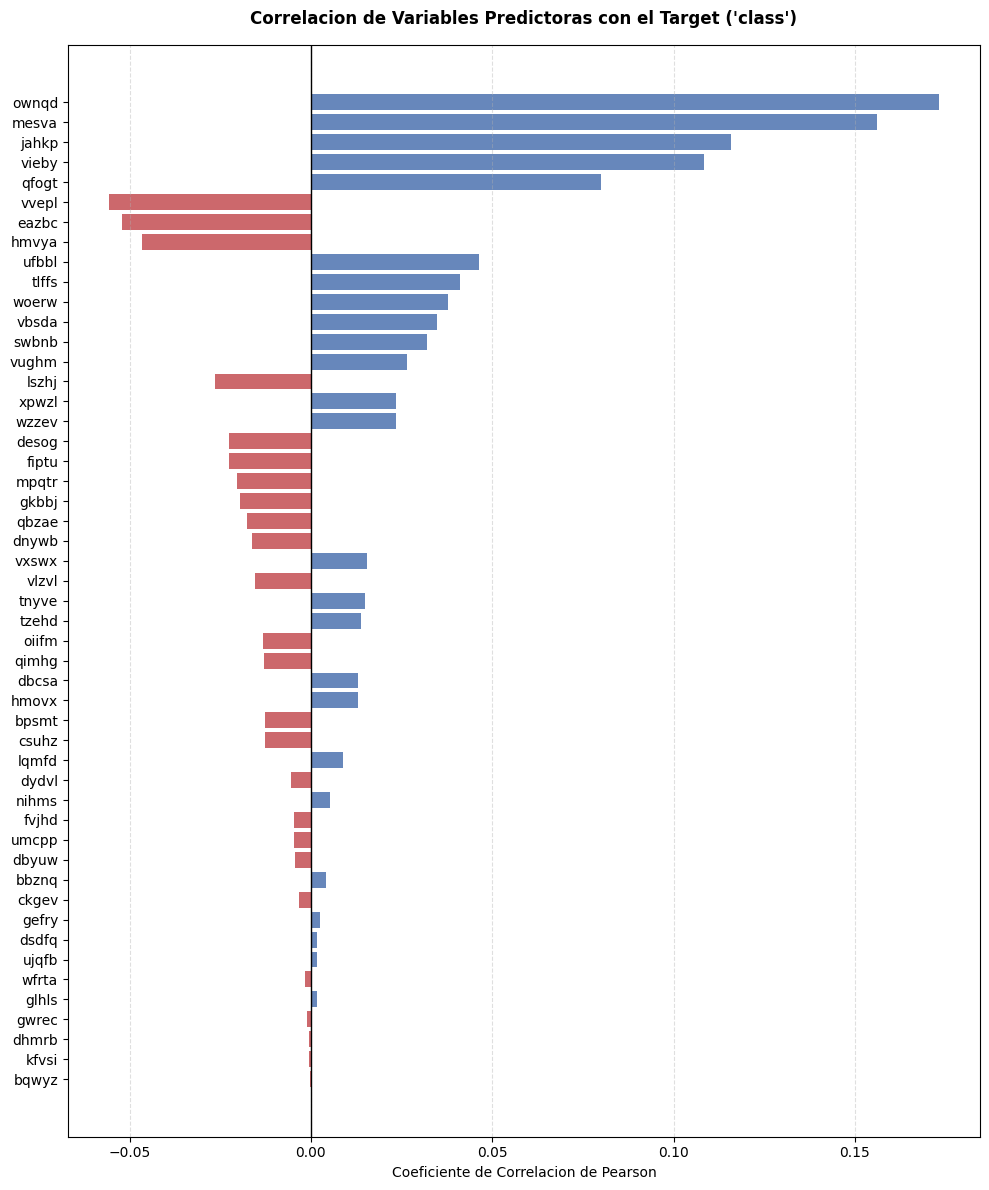

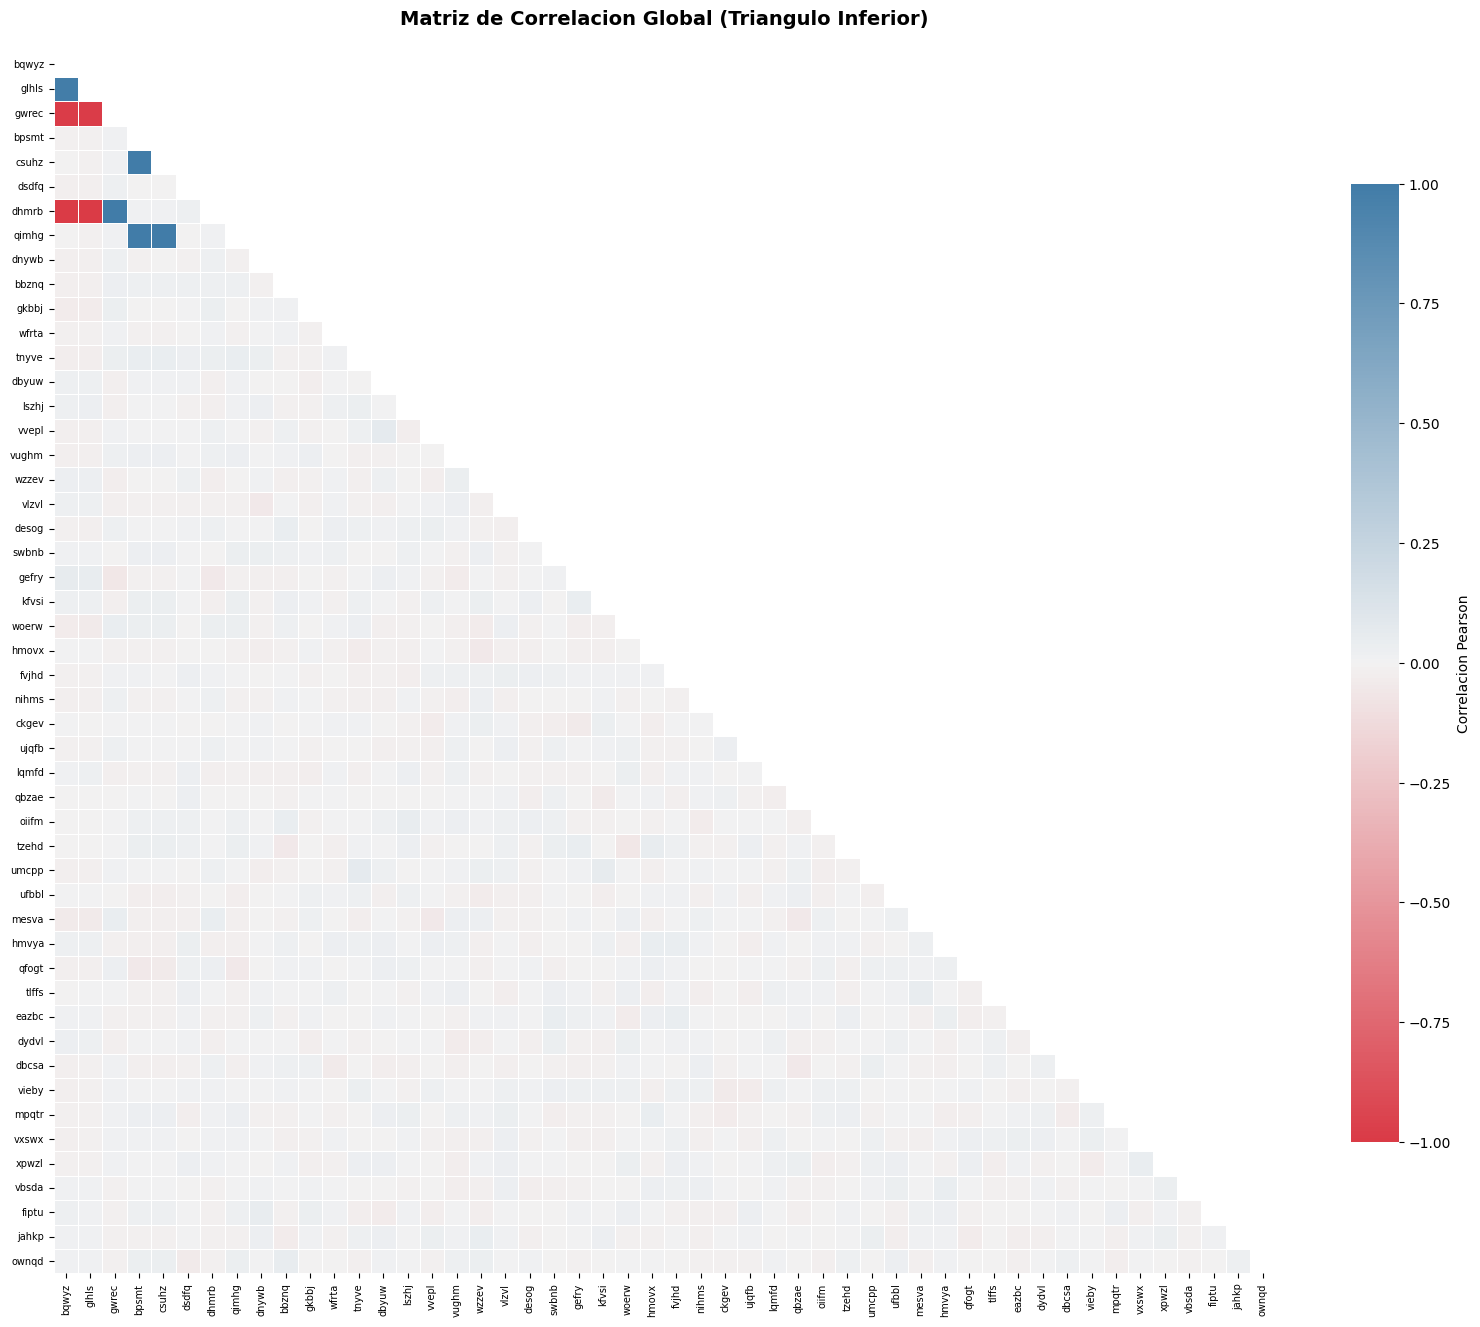


Pares de variables con alta correlacion (Multicolinealidad > 0.70):


,Variable 1,Variable 2,Correlacion
353,qimhg,bpsmt,0.999502
354,qimhg,csuhz,0.999366
203,csuhz,bpsmt,0.998825
302,dhmrb,gwrec,0.995369
301,dhmrb,glhls,-0.995193
300,dhmrb,bqwyz,-0.995072
101,gwrec,glhls,-0.990507
100,gwrec,bqwyz,-0.990369
50,glhls,bqwyz,0.990268


In [7]:
# == 6. ANALISIS DE CORRELACION ===============================================
import seaborn as sns

# Calcular matriz de correlacion (Pearson) en los datos de entrenamiento
corr_matrix = train_df.corr(method='pearson')

# -----------------------------------------------------------------------------
# A. RANKING DE CORRELACION CON EL TARGET (Variable Objetivo)
# -----------------------------------------------------------------------------
# Extraer valores crudos para la clase, limpiando NA y la propia clase
target_corr = corr_matrix['class'].drop('class').dropna()

# Ordenar por magnitud absoluta, pero conservando el signo original en el grafico
target_corr_sorted = target_corr.iloc[target_corr.abs().argsort()][::-1]

fig, ax = plt.subplots(figsize=(10, 12))

# Graficar barras: Azul para positiva, Rojo para negativa
colors = ['#4C72B0' if x >= 0 else '#C44E52' for x in target_corr_sorted]
ax.barh(target_corr_sorted.index[::-1], target_corr_sorted.values[::-1], color=colors[::-1], alpha=0.85)

ax.set_title('Correlacion de Variables Predictoras con el Target (\'class\')', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Coeficiente de Correlacion de Pearson')
ax.axvline(0, color='black', linewidth=1)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# B. MAPA DE CALOR: CORRELACION GLOBAL Y MULTICOLINEALIDAD
# -----------------------------------------------------------------------------
cols_plot = target_corr.index.tolist()
corr_features = train_df[cols_plot].corr()

# Generar mascara para la parte superior del triangulo (redundante)
mask = np.triu(np.ones_like(corr_features, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
cmap = sns.diverging_palette(10, 240, n=9, as_cmap=True)

sns.heatmap(corr_features, mask=mask, cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7, "label": "Correlacion Pearson"},
            xticklabels=True, yticklabels=True, ax=ax)

ax.set_title('Matriz de Correlacion Global (Triangulo Inferior)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# C. TOP PARES ALTAMENTE CORRELACIONADOS (Alerta Multicolinealidad)
# -----------------------------------------------------------------------------
# Aplanar matriz diagonal inferior
stacked_corr = corr_features.mask(mask).stack().reset_index()
stacked_corr.columns = ['Variable 1', 'Variable 2', 'Correlacion']

# Filtrar los pares con correlacion absoluta > 0.70
high_corr = stacked_corr[stacked_corr['Correlacion'].abs() > 0.70].sort_values(by='Correlacion', key=abs, ascending=False)
print("\nPares de variables con alta correlacion (Multicolinealidad > 0.70):")
if not high_corr.empty:
    display(high_corr)
else:
    print(" > No hay variables con correlacion de Pearson absoluta mayor a 0.70.")

## 7. Análisis de Varianza Cero y Baja (Constantes y Cuasi-Constantes)

### Teoría: Variables con Varianza Cero
Las variables con varianza cero tienen exactamente el mismo valor para todas las observaciones del dataset. En los algoritmos supervisados, estas características no aportan ninguna información útil para discriminar entre las distintas clases (o predecir un valor numérico continuo), pues no muestran variación alguna.

Mantener este tipo de variables puede ocasionar problemas matemáticos (como divisiones por cero al estandarizar o calcular correlaciones) y aumenta innecesariamente la dimensionalidad (agravando la *maldición de la dimensionalidad*). Por esta razón, el procedimiento estándar es identificarlas y eliminarlas.

Adicionalmente, es útil observar las variables con varianza **muy baja** (cuasi-constantes), ya que en la mayoría de los casos actúan prácticamente como una constante y aportan más ruido que señal.

In [8]:
# Cálculo de la varianza para todas las variables predictoras numéricas
feature_cols = [c for c in train_df.select_dtypes(include='number').columns if c != 'class']
variances = train_df[feature_cols].var()

# Identificar variables con varianza cero
zero_variance_cols = variances[variances == 0].index.tolist()

print(f"Número de variables con varianza cero en train: {len(zero_variance_cols)}")
if len(zero_variance_cols) > 0:
    print(f"Variables con varianza cero (candidatas a ser eliminadas): {zero_variance_cols}")
else:
    print("✅ No se encontraron variables predictoras con varianza cero en el conjunto de entrenamiento.")

# Identificar variables con varianza muy baja (cuasi-constantes)
umbral_varianza = 0.01
low_variance_cols = variances[(variances > 0) & (variances < umbral_varianza)].sort_values()
print(f"\nNúmero de variables con varianza muy baja (< {umbral_varianza}) en train: {len(low_variance_cols)}")
if len(low_variance_cols) > 0:
    print("Variables con varianza muy baja:")
    display(low_variance_cols.to_frame(name='Varianza'))

Número de variables con varianza cero en train: 0
✅ No se encontraron variables predictoras con varianza cero en el conjunto de entrenamiento.

Número de variables con varianza muy baja (< 0.01) en train: 2
Variables con varianza muy baja:


,Varianza
dsdfq,0.000090
gefry,0.009335


## 4. Análisis de Normalidad (Test de Shapiro-Wilk)

### Teoría: Normalidad y el Test de Shapiro-Wilk
En estadística, la suposición de normalidad es un requisito previo para muchos algoritmos paramétricos (como Regresión Lineal, Regresión Logística o Análisis Discriminante Lineal). Si las variables predictoras no siguen una distribución normal, los modelos lineales podrían presentar problemas de rendimiento, y podríamos necesitar aplicar transformaciones (como logarítmicas, raíz cuadrada o Box-Cox) o decantarnos por modelos no paramétricos (como Árboles de Decisión, Random Forest o XGBoost).

El **Test de Shapiro-Wilk** (Shapiro y Wilk, 1965) evalúa la hipótesis nula ($H_0$) de que una muestra proviene de una población con distribución normal.
- **Estadístico $W$**: Un valor cercano a 1 indica que los datos se ajustan fuertemente a la normalidad. Valores más bajos indican desviaciones.
- **P-valor (p-value)**: Si es menor que un nivel de significancia (usualmente $\alpha = 0.05$), rechazamos $H_0$ y concluimos que los datos **no** son normales. Si es mayor, no podemos rechazar $H_0$.

> **Nota Práctica:** El test de Shapiro-Wilk es muy sensible a tamaños de muestra grandes. Con muchos datos (como nuestro caso, N=3000), desviaciones minúsculas de la normalidad pueden dar p-valores muy bajos. Sin embargo, ordenar las variables por el estadístico $W$ nos da una buena métrica relativa de cuáles se desvían más de la campana de Gauss.

In [9]:
from scipy.stats import shapiro
from typing import Dict, List, Any

def run_shapiro_wilk(df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Ejecuta el test de Shapiro-Wilk para cada variable numérica en un DataFrame.
    
    Args:
        df: DataFrame de Pandas con las variables numéricas.
        alpha: Nivel de significancia para el test.
        
    Returns:
        DataFrame con los resultados (Estadístico W, p-valor y un flag de normalidad).
    """
    results: List[Dict[str, Any]] = []
    
    # Excluimos la variable objetivo 'class' de este análisis, ya que es categórica
    features: pd.DataFrame = df.drop(columns=['class']) if 'class' in df.columns else df
    
    for col in features.columns:
        # SciPy's shapiro lanza un warning si N > 5000, pero nuestro N es 3000
        # Calculamos el estadístico y el p-valor
        stat, p_value = shapiro(features[col].dropna())
        
        # Almacenamos los resultados iterativos en un diccionario
        results.append({
            'Variable': col,
            'W_Statistic': stat,
            'P_Value': p_value,
            'Is_Normal': p_value > alpha
        })
        
    # Convertimos la lista de diccionarios a un DataFrame de Pandas para su visualización
    results_df: pd.DataFrame = pd.DataFrame(results)
    return results_df

# Analizamos todas las variables del conjunto de entrenamiento
shapiro_results: pd.DataFrame = run_shapiro_wilk(train_df)

print("=========================================================")
print(" Análisis de Normalidad (Todas las Variables)")
print("=========================================================")
display(shapiro_results)

# Seleccionamos las 10 variables 'más importantes' en términos de desviación de la normalidad.
# Ordenando por el estadístico W de menor a mayor, obtenemos las que menos forma normal tienen.
top_10_non_normal: pd.DataFrame = shapiro_results.sort_values(by='W_Statistic', ascending=True).head(10)

print("\n=========================================================")
print(" Top 10 Variables con Mayor Desviación de la Normalidad")
print(" (Ordenadas por menor estadístico W)")
print("=========================================================")
display(top_10_non_normal.reset_index(drop=True))

 Análisis de Normalidad (Todas las Variables)


,Variable,W_Statistic,P_Value,Is_Normal
0,bqwyz,0.999742,9.824189e-01,True
1,glhls,0.999723,9.729136e-01,True
2,gwrec,0.999746,9.840769e-01,True
3,bpsmt,0.999464,5.872441e-01,True
4,csuhz,0.999454,5.689760e-01,True
5,dsdfq,0.952064,2.774355e-30,False
6,dhmrb,0.999734,9.787550e-01,True
7,qimhg,0.999439,5.400154e-01,True
8,dnywb,0.951837,2.413032e-30,False
9,bbznq,0.999370,4.223205e-01,True



 Top 10 Variables con Mayor Desviación de la Normalidad
 (Ordenadas por menor estadístico W)


,Variable,W_Statistic,P_Value,Is_Normal
0,vlzvl,0.949793,7.008123e-31,False
1,dnywb,0.951837,2.413032e-30,False
2,dsdfq,0.952064,2.774355e-30,False
3,gefry,0.953269,5.879673e-30,False
4,kfvsi,0.954740,1.500878e-29,False
5,lszhj,0.954789,1.548992e-29,False
6,dbyuw,0.955768,2.931313e-29,False
7,tnyve,0.956598,5.075828e-29,False
8,wfrta,0.957350,8.404251e-29,False
9,ownqd,0.996137,5.403725e-07,False


## 4. Análisis de Normalidad (Test de Shapiro-Wilk)

### Teoría: Normalidad y el Test de Shapiro-Wilk
En estadística, la suposición de normalidad es un requisito previo para muchos algoritmos paramétricos (como Regresión Lineal, Regresión Logística o Análisis Discriminante Lineal). Si las variables predictoras no siguen una distribución normal, los modelos lineales podrían presentar problemas de rendimiento, y podríamos necesitar aplicar transformaciones (como logarítmicas, raíz cuadrada o Box-Cox) o decantarnos por modelos no paramétricos (como Árboles de Decisión, Random Forest o XGBoost).

El **Test de Shapiro-Wilk** (Shapiro y Wilk, 1965) evalúa la hipótesis nula ($H_0$) de que una muestra proviene de una población con distribución normal.
- **Estadístico $W$**: Un valor cercano a 1 indica que los datos se ajustan fuertemente a la normalidad. Valores más bajos indican desviaciones.
- **P-valor (p-value)**: Si es menor que un nivel de significancia (usualmente $\alpha = 0.05$), rechazamos $H_0$ y concluimos que los datos **no** son normales. Si es mayor, no podemos rechazar $H_0$.

> **Nota Práctica:** El test de Shapiro-Wilk es muy sensible a tamaños de muestra grandes. Con muchos datos (como nuestro caso, N=3000), desviaciones minúsculas de la normalidad pueden dar p-valores muy bajos. Sin embargo, ordenar las variables por el estadístico $W$ nos da una buena métrica relativa de cuáles se desvían más de la campana de Gauss.

In [10]:
from scipy.stats import shapiro
from typing import Dict, List, Any

def run_shapiro_wilk(df: pd.DataFrame, alpha: float = 0.05) -> pd.DataFrame:
    """
    Ejecuta el test de Shapiro-Wilk para cada variable numérica en un DataFrame.
    
    Args:
        df: DataFrame de Pandas con las variables numéricas.
        alpha: Nivel de significancia para el test.
        
    Returns:
        DataFrame con los resultados (Estadístico W, p-valor y un flag de normalidad).
    """
    results: List[Dict[str, Any]] = []
    
    # Excluimos la variable objetivo 'class' de este análisis, ya que es categórica
    features: pd.DataFrame = df.drop(columns=['class']) if 'class' in df.columns else df
    
    for col in features.columns:
        # SciPy's shapiro lanza un warning si N > 5000, pero nuestro N es 3000
        # Calculamos el estadístico y el p-valor
        stat, p_value = shapiro(features[col].dropna())
        
        # Almacenamos los resultados iterativos en un diccionario
        results.append({
            'Variable': col,
            'W_Statistic': stat,
            'P_Value': p_value,
            'Is_Normal': p_value > alpha
        })
        
    # Convertimos la lista de diccionarios a un DataFrame de Pandas para su visualización
    results_df: pd.DataFrame = pd.DataFrame(results)
    return results_df

# Analizamos todas las variables del conjunto de entrenamiento
shapiro_results: pd.DataFrame = run_shapiro_wilk(train_df)

print("=========================================================")
print(" Análisis de Normalidad (Todas las Variables)")
print("=========================================================")
display(shapiro_results)

# Seleccionamos las 10 variables 'más importantes' en términos de desviación de la normalidad.
# Ordenando por el estadístico W de menor a mayor, obtenemos las que menos forma normal tienen.
top_10_non_normal: pd.DataFrame = shapiro_results.sort_values(by='W_Statistic', ascending=True).head(10)

print("\n=========================================================")
print(" Top 10 Variables con Mayor Desviación de la Normalidad")
print(" (Ordenadas por menor estadístico W)")
print("=========================================================")
display(top_10_non_normal.reset_index(drop=True))

 Análisis de Normalidad (Todas las Variables)


,Variable,W_Statistic,P_Value,Is_Normal
0,bqwyz,0.999742,9.824189e-01,True
1,glhls,0.999723,9.729136e-01,True
2,gwrec,0.999746,9.840769e-01,True
3,bpsmt,0.999464,5.872441e-01,True
4,csuhz,0.999454,5.689760e-01,True
5,dsdfq,0.952064,2.774355e-30,False
6,dhmrb,0.999734,9.787550e-01,True
7,qimhg,0.999439,5.400154e-01,True
8,dnywb,0.951837,2.413032e-30,False
9,bbznq,0.999370,4.223205e-01,True



 Top 10 Variables con Mayor Desviación de la Normalidad
 (Ordenadas por menor estadístico W)


,Variable,W_Statistic,P_Value,Is_Normal
0,vlzvl,0.949793,7.008123e-31,False
1,dnywb,0.951837,2.413032e-30,False
2,dsdfq,0.952064,2.774355e-30,False
3,gefry,0.953269,5.879673e-30,False
4,kfvsi,0.954740,1.500878e-29,False
5,lszhj,0.954789,1.548992e-29,False
6,dbyuw,0.955768,2.931313e-29,False
7,tnyve,0.956598,5.075828e-29,False
8,wfrta,0.957350,8.404251e-29,False
9,ownqd,0.996137,5.403725e-07,False
